# Machine Learning Lab (23CSE301) – Exercise Solutions
**Chapter 12**


In [1]:
# ---- Common imports and dataset loader ----
import os, re, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

# ---- Dataset loader ----
DATA_DIR = "data"
def load_data(filename, url, **read_csv_kwargs):
    """Read a real dataset. Uses ./data/<filename> if present (e.g. downloaded from Kaggle);
    otherwise downloads the public copy given in `url` and caches it in ./data/."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        os.makedirs(DATA_DIR, exist_ok=True)
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as resp, open(path, "wb") as f:
            f.write(resp.read())
    return pd.read_csv(path, **read_csv_kwargs)

print("Libraries loaded")

Libraries loaded


# 12.6 Random Forest – Exercise
## Exercise 1 – Fruit basket: which fruit is likely to be taken often?
`n` bootstrap samples are drawn from the basket and one decision tree is built per sample. In classification, the forest returns the **majority vote** of the trees:

* Tree-1 → **Class A (Apple)**
* Tree-2 → **Class A (Apple)**
* Tree-n → **Class B (Banana)**

Votes from the individual trees:
  Tree-1  -> Apple (Class A)
  Tree-2  -> Apple (Class A)
  Tree-n  -> Banana (Class B)

Vote count: {'Apple (Class A)': 2, 'Banana (Class B)': 1}

Majority voting -> Final class: Apple (Class A)  (2 of 3 trees)


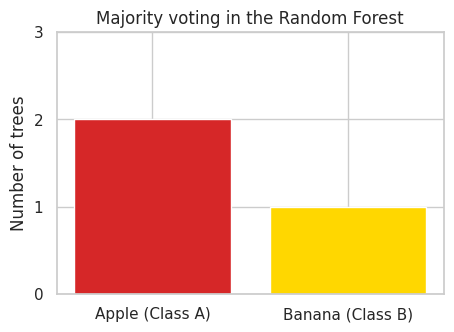

In [52]:
from collections import Counter

tree_outputs = {"Tree-1": "Apple (Class A)", "Tree-2": "Apple (Class A)", "Tree-n": "Banana (Class B)"}
votes = Counter(tree_outputs.values())

print("Votes from the individual trees:")
for tree_name, out in tree_outputs.items():
    print(f"  {tree_name:<7} -> {out}")

print("\nVote count:", dict(votes))
winner, count = votes.most_common(1)[0]
print(f"\nMajority voting -> Final class: {winner}  ({count} of {len(tree_outputs)} trees)")

plt.figure(figsize=(5, 3.4))
plt.bar(votes.keys(), votes.values(), color=["tab:red", "gold"])
plt.ylabel("Number of trees"); plt.title("Majority voting in the Random Forest"); plt.yticks(range(0, 4)); plt.show()

**Answer:** the **Apple** is the fruit likely to be taken most often – two of the three trees vote Class A, so the majority-voting step outputs **Apple** as the final class. (For regression the forest would instead *average* the trees' outputs.)